Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')
               score  thumbsUpCount
count  136224.000000  136224.000000
mean        4.497064       0.522287
std         1.090412      12.595311
min         1.000000       0.000000
25%         5.000000       0.000000
50%         5.000000       0.000000
75%         5.000000       0.000000
max         5.000000    1193.000000
                               reviewId              userName  \
0  a1197425-d684-4aad-b662-73492807730c           Kamal Farai   
1  ade3a4f8-25d2-42cd-bbd0-e171e4c12e00     Mackenson Florial   
2  c47ac382-bdb4-4ec8-93fd-5772d824b7f2  Je-an Carlo Cornelio   
3  0076e5f4-37c4-48e9-bc45-233b91bbb013           Hussein Sar   
4  922e80fa-346d-4d6c-993d-f5869bf0116d          Progress Kim   

                                             content  score  thumbsUpCount  \
0  the app very organized and lightweight than na...      5      

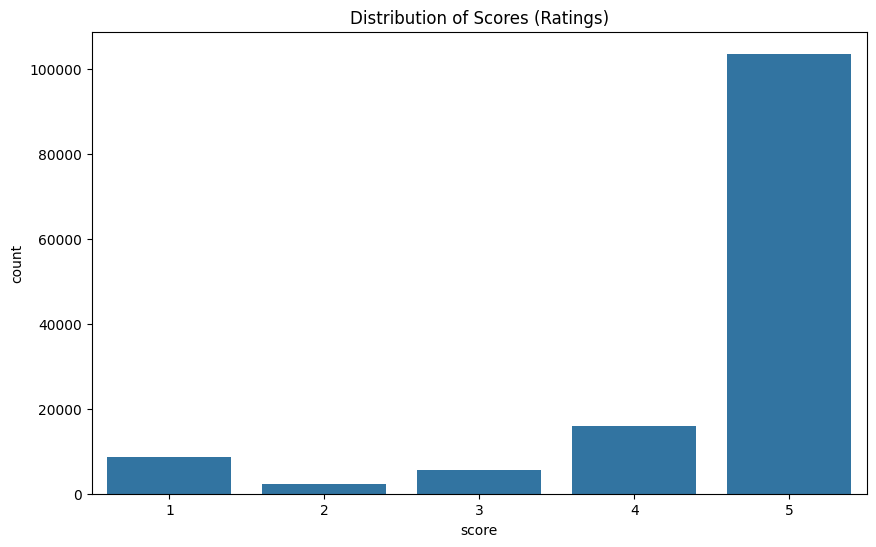

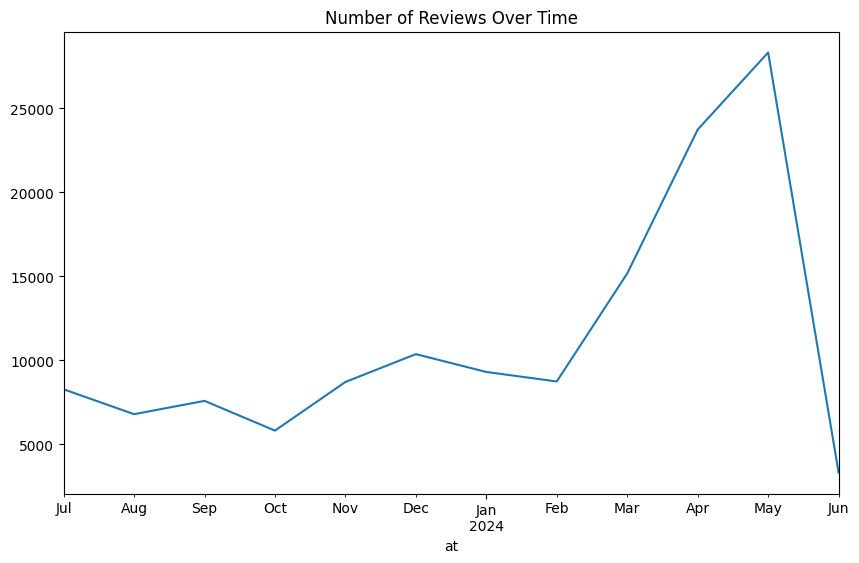

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('chatgpt_reviews.csv')

# Display the columns of the dataset
print(df.columns)

# Display basic statistics
print(df.describe())

# Check the first few rows to understand the data
print(df.head())

# Visualize the distribution of scores (ratings)
plt.figure(figsize=(10, 6))
sns.countplot(x='score', data=df)
plt.title('Distribution of Scores (Ratings)')
plt.show()

# Visualize the number of reviews over time
df['at'] = pd.to_datetime(df['at'])  # Ensure the 'at' column is in datetime format
df.set_index('at', inplace=True)
df.resample('M').size().plot(figsize=(10, 6))
plt.title('Number of Reviews Over Time')
plt.show()


In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv('chatgpt_reviews.csv')

# Display the first few rows of the dataset
df.head()


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,a1197425-d684-4aad-b662-73492807730c,Kamal Farai,the app very organized and lightweight than na...,5,0,1.2024.143,2024-06-04 22:27:37,1.2024.143
1,ade3a4f8-25d2-42cd-bbd0-e171e4c12e00,Mackenson Florial,Interesting but this app can't generate pictur...,3,0,1.2024.143,2024-06-04 22:24:08,1.2024.143
2,c47ac382-bdb4-4ec8-93fd-5772d824b7f2,Je-an Carlo Cornelio,This app helps me to answer quizes and anything,5,0,1.2024.143,2024-06-04 22:23:04,1.2024.143
3,0076e5f4-37c4-48e9-bc45-233b91bbb013,Hussein Sar,good App,5,0,1.2024.143,2024-06-04 22:22:44,1.2024.143
4,922e80fa-346d-4d6c-993d-f5869bf0116d,Progress Kim,good 👍,5,0,1.2024.143,2024-06-04 22:11:17,1.2024.143


In [8]:
# Display the columns of the dataset
print(df.columns)

# Display basic statistics
print(df.describe())

# Check the first few rows to understand the data
print(df.head())


Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')
               score  thumbsUpCount
count  136224.000000  136224.000000
mean        4.497064       0.522287
std         1.090412      12.595311
min         1.000000       0.000000
25%         5.000000       0.000000
50%         5.000000       0.000000
75%         5.000000       0.000000
max         5.000000    1193.000000
                               reviewId              userName  \
0  a1197425-d684-4aad-b662-73492807730c           Kamal Farai   
1  ade3a4f8-25d2-42cd-bbd0-e171e4c12e00     Mackenson Florial   
2  c47ac382-bdb4-4ec8-93fd-5772d824b7f2  Je-an Carlo Cornelio   
3  0076e5f4-37c4-48e9-bc45-233b91bbb013           Hussein Sar   
4  922e80fa-346d-4d6c-993d-f5869bf0116d          Progress Kim   

                                             content  score  thumbsUpCount  \
0  the app very organized and lightweight than na...      5      

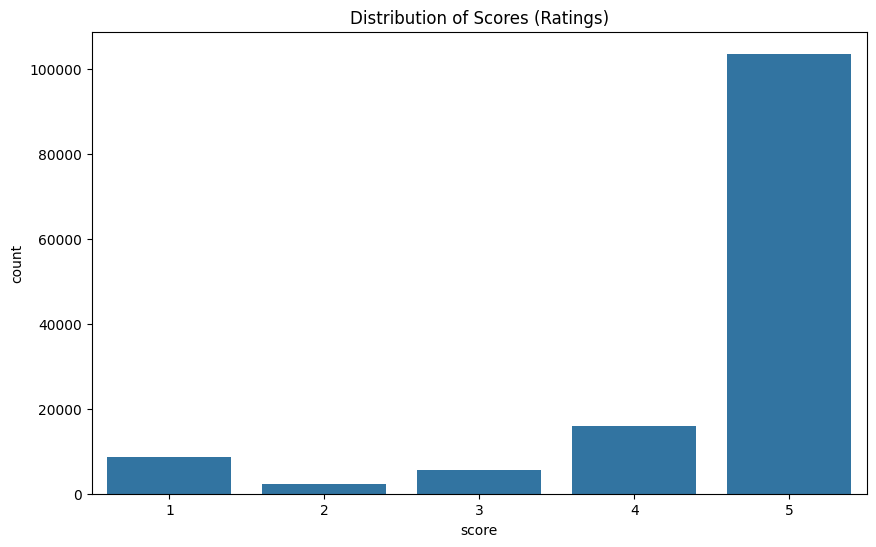

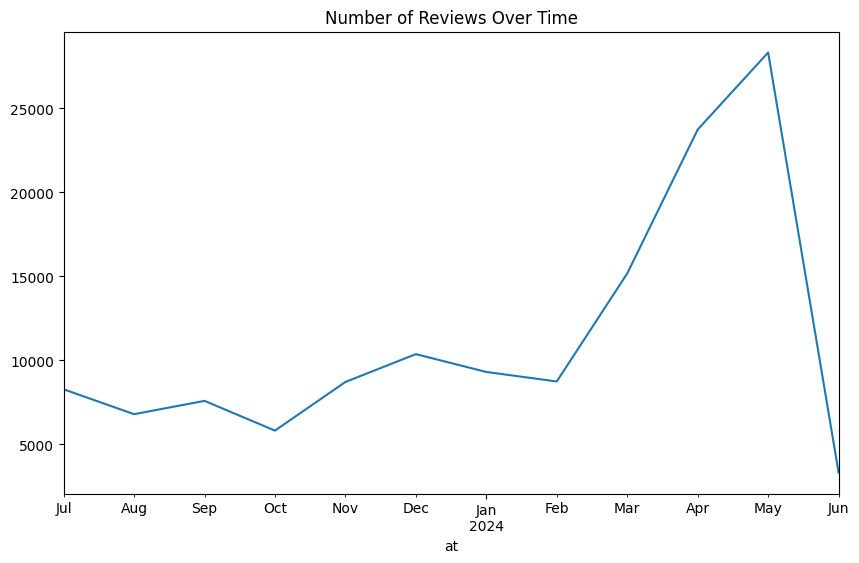

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of scores (ratings)
plt.figure(figsize=(10, 6))
sns.countplot(x='score', data=df)
plt.title('Distribution of Scores (Ratings)')
plt.show()

# Visualize the number of reviews over time
df['at'] = pd.to_datetime(df['at'])  # Ensure the 'at' column is in datetime format
df.set_index('at', inplace=True)
df.resample('M').size().plot(figsize=(10, 6))
plt.title('Number of Reviews Over Time')
plt.show()


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text data to numerical data (using TF-IDF for example)
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['content'].values.astype('U')).toarray()
y = df['score'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
print(f'Linear Regression MSE: {mse_lr}')


Linear Regression MSE: 0.7231041102634613


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model
nn_model = Sequential()
nn_model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
nn_model.add(Dense(64, activation='relu'))
nn_model.add(Dense(1))

# Compile the model
nn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
nn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Make predictions
y_pred_nn = nn_model.predict(X_test)

# Evaluate the model
mse_nn = mean_squared_error(y_test, y_pred_nn)
print(f'Neural Network MSE: {mse_nn}')


Epoch 1/10
2725/2725 [==============================] - 16s 6ms/step - loss: 1.0312 - val_loss: 0.8346
Epoch 2/10
2725/2725 [==============================] - 15s 5ms/step - loss: 0.7315 - val_loss: 0.7959
Epoch 3/10
2725/2725 [==============================] - 18s 6ms/step - loss: 0.6546 - val_loss: 0.7950
Epoch 4/10
2725/2725 [==============================] - 16s 6ms/step - loss: 0.5938 - val_loss: 0.7693
Epoch 5/10
2725/2725 [==============================] - 16s 6ms/step - loss: 0.5495 - val_loss: 0.7771
Epoch 6/10
2725/2725 [==============================] - 15s 6ms/step - loss: 0.5139 - val_loss: 0.7765
Epoch 7/10
2725/2725 [==============================] - 15s 6ms/step - loss: 0.4895 - val_loss: 0.7711
Epoch 8/10
2725/2725 [==============================] - 14s 5ms/step - loss: 0.4708 - val_loss: 0.7691
Epoch 9/10
2725/2725 [==============================] - 14s 5ms/step - loss: 0.4544 - val_loss: 0.7724
Epoch 10/10
852/852 [==============================] - 2s 2ms/step
Neural

In [13]:
print(f'Linear Regression MSE: {mse_lr}')
print(f'Neural Network MSE: {mse_nn}')


Linear Regression MSE: 0.7231041102634613
Neural Network MSE: 0.7609721357320111


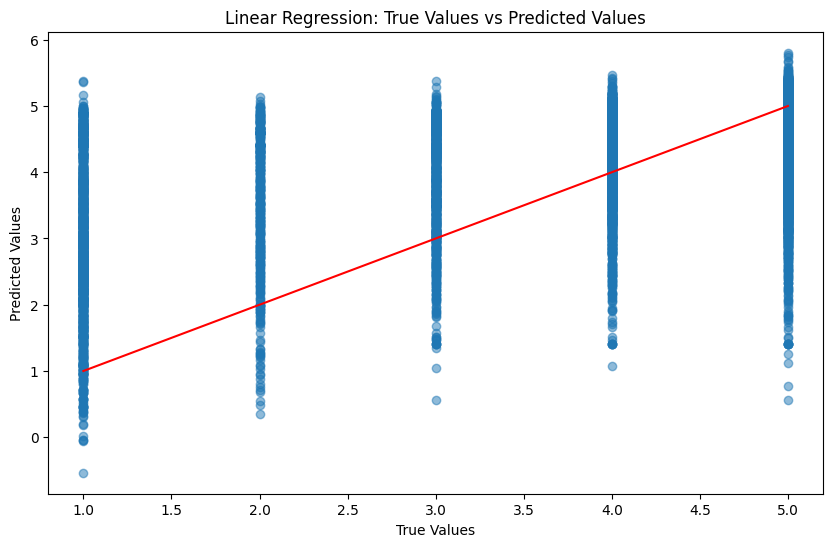

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Scatter plot of the true values vs. the predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([np.min(y_test), np.max(y_test)], [np.min(y_test), np.max(y_test)], color='red')  # Line of perfect prediction
plt.title('Linear Regression: True Values vs Predicted Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.show()


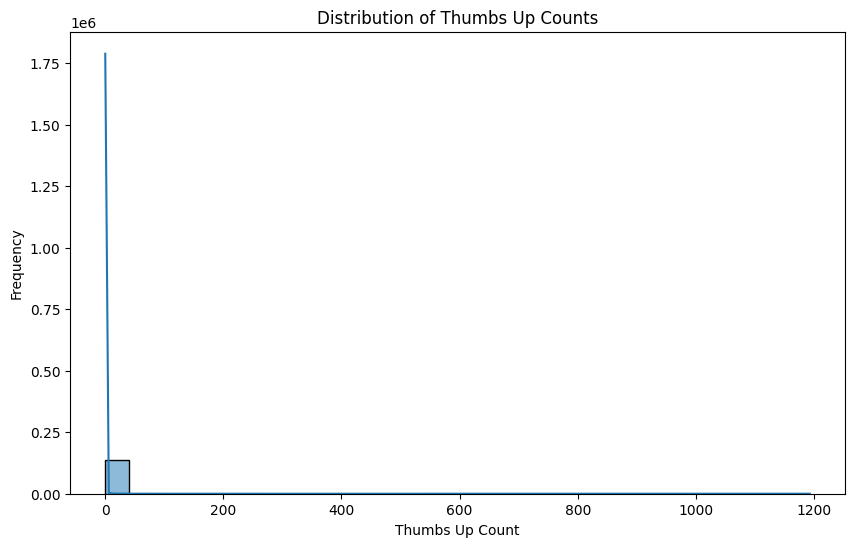

In [15]:
# Visualize the distribution of thumbs up counts
plt.figure(figsize=(10, 6))
sns.histplot(df['thumbsUpCount'], bins=30, kde=True)
plt.title('Distribution of Thumbs Up Counts')
plt.xlabel('Thumbs Up Count')
plt.ylabel('Frequency')
plt.show()


In [16]:
!pip install wordcloud


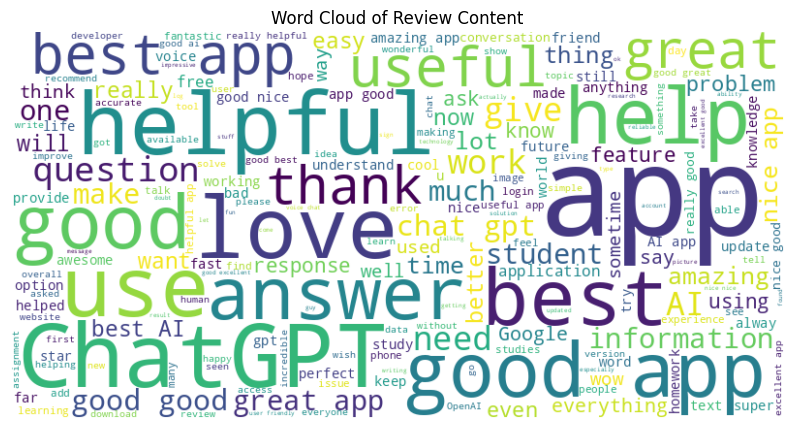

In [19]:
from wordcloud import WordCloud

# Generate a word cloud from the review content
text = " ".join(review for review in df['content'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Content')
plt.show()


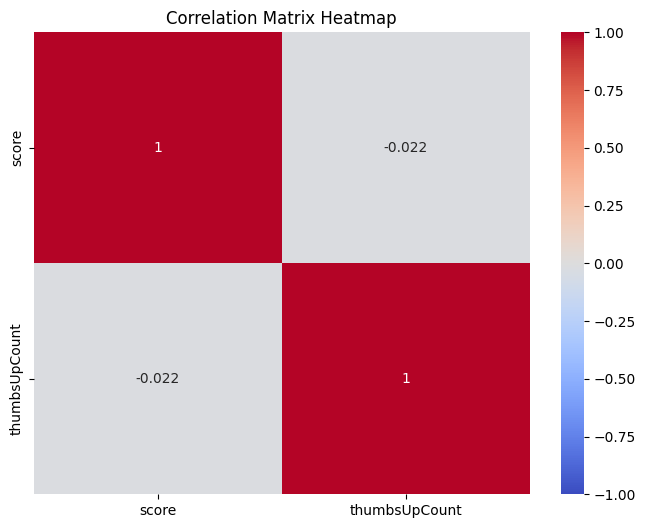

In [20]:
# Compute the correlation matrix
correlation_matrix = df[['score', 'thumbsUpCount']].corr()

# Generate a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()


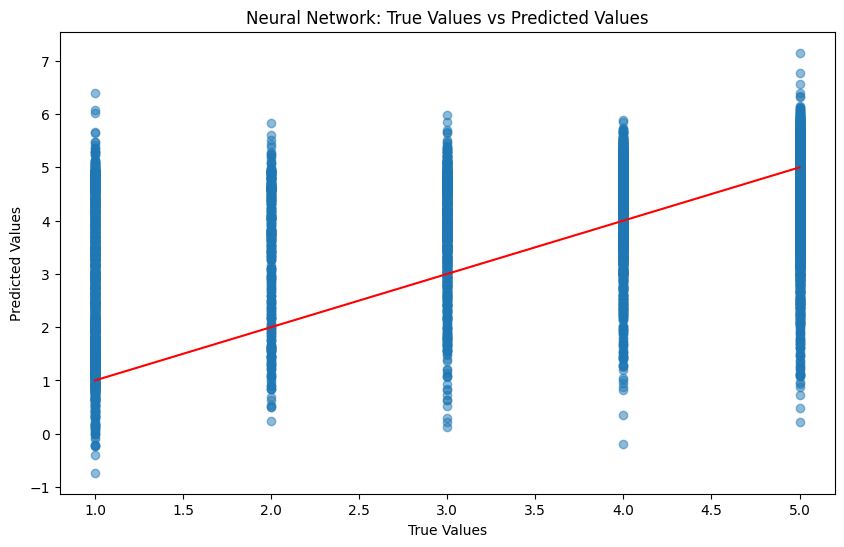

In [22]:
# Scatter plot of the true values vs. the predicted values from the neural network
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.5)
plt.plot([np.min(y_test), np.max(y_test)], [np.min(y_test), np.max(y_test)], color='red')  # Line of perfect prediction
plt.title('Neural Network: True Values vs Predicted Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.show()


Epoch 1/10
2725/2725 [==============================] - 18s 7ms/step - loss: 0.4304 - val_loss: 0.7691
Epoch 2/10
2725/2725 [==============================] - 15s 5ms/step - loss: 0.4230 - val_loss: 0.7677
Epoch 3/10
2725/2725 [==============================] - 15s 5ms/step - loss: 0.4143 - val_loss: 0.7792
Epoch 4/10
2725/2725 [==============================] - 15s 5ms/step - loss: 0.4080 - val_loss: 0.7706
Epoch 5/10
2725/2725 [==============================] - 18s 7ms/step - loss: 0.4019 - val_loss: 0.7686
Epoch 6/10
2725/2725 [==============================] - 15s 5ms/step - loss: 0.3953 - val_loss: 0.7791
Epoch 7/10
2725/2725 [==============================] - 24s 9ms/step - loss: 0.3911 - val_loss: 0.7688
Epoch 8/10
2725/2725 [==============================] - 14s 5ms/step - loss: 0.3872 - val_loss: 0.7717
Epoch 9/10
2725/2725 [==============================] - 31s 11ms/step - loss: 0.3827 - val_loss: 0.7660
Epoch 10/10
2725/2725 [==============================] - 15s 5ms/step - 

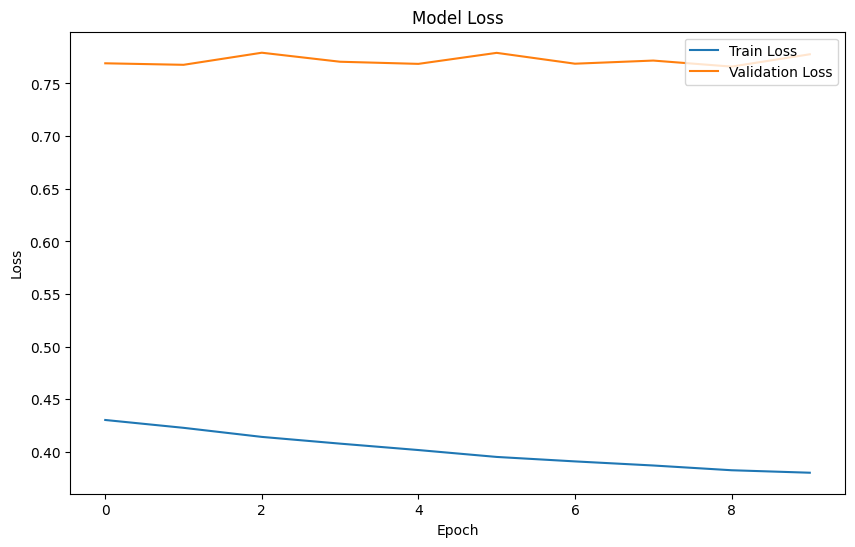

In [23]:
# Assuming you have stored the history of the training process
history = nn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


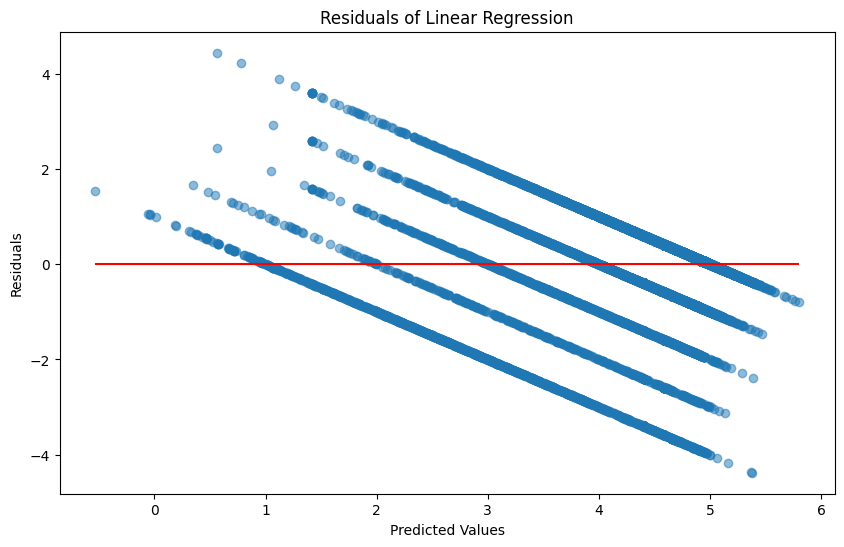

In [24]:
# Residual plot
residuals = y_test - y_pred_lr

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_lr, residuals, alpha=0.5)
plt.hlines(y=0, xmin=np.min(y_pred_lr), xmax=np.max(y_pred_lr), color='red')
plt.title('Residuals of Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()


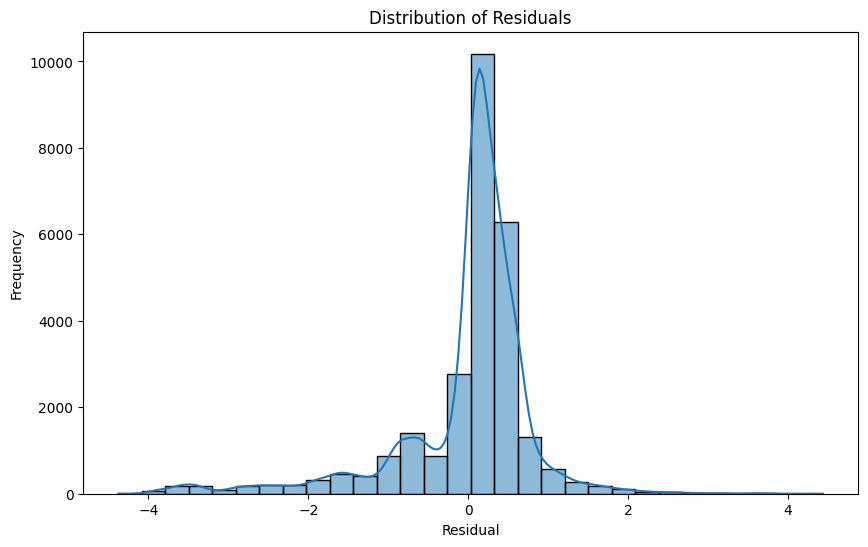

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()


<Figure size 1000x600 with 0 Axes>

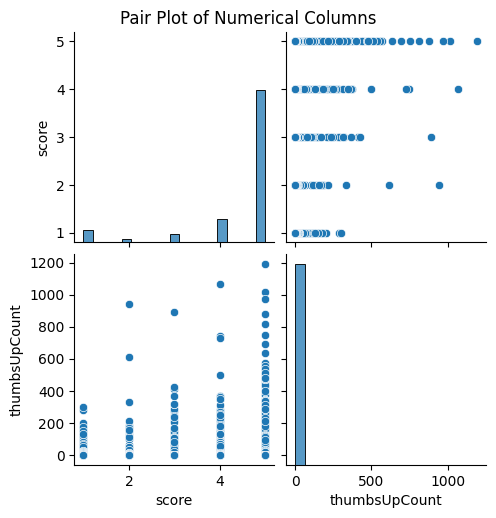

In [26]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('chatgpt_reviews.csv')

# Select the numerical columns for the pair plot
numerical_columns = ['score', 'thumbsUpCount']

# Create the pair plot
plt.figure(figsize=(10, 6))
sns.pairplot(df[numerical_columns])
plt.suptitle('Pair Plot of Numerical Columns', y=1.02)  # Adjust the title position
plt.show()


In [28]:
!pip install ann_visualizer
!pip install graphviz


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from ann_visualizer.visualize import ann_viz

# Load the dataset
df = pd.read_csv('chatgpt_reviews.csv')

# Convert text data to numerical data (using TF-IDF for example)
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['content'].values.astype('U')).toarray()
y = df['score'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the Neural Network model
nn_model = Sequential()
nn_model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
nn_model.add(Dense(64, activation='relu'))
nn_model.add(Dense(1))

# Compile the Neural Network model
nn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the Neural Network model
history = nn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

# Make predictions with the Neural Network
y_pred_nn = nn_model.predict(X_test).flatten()  # Flatten to ensure it's a 1D array

# Evaluate the Neural Network model
mse_nn = mean_squared_error(y_test, y_pred_nn)
print(f'Neural Network MSE: {mse_nn}')

# Visualize the Neural Network
ann_viz(nn_model, title="Neural Network Architecture")

# Visualize the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()
